In [44]:
import pandas as pd
import matplotlib.pyplot as  plt
import seaborn as sns
import numpy as np
%matplotlib inline

In [45]:
df=pd.read_csv('Telco_cleaned.csv')

In [46]:
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [47]:
df.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

Feature selection

In [48]:
df['Churn'].value_counts()

,count
Churn,
0,5174
1,1869


In [49]:
df = df.drop('customerID', axis=1, errors='ignore')

START THE TRAINING

In [50]:
X=df.drop('Churn',axis=1)
y=df['Churn']

In [51]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42)

In [52]:
X_train.shape,y_train.shape,y_test.shape

((5634, 30), (5634,), (1409,))

In [53]:
X.corr()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
SeniorCitizen,1.000000,0.016567,0.220173,0.103006,-0.001874,0.016479,-0.211185,0.008576,-0.008576,0.142948,...,-0.182742,0.105378,-0.182742,0.120176,-0.046262,-0.117000,0.156530,-0.024135,0.171718,-0.153477
tenure,0.016567,1.000000,0.247900,0.826178,0.005106,0.379697,0.159712,0.008448,-0.008448,0.331941,...,-0.039062,0.279756,-0.039062,0.286111,0.202570,0.558533,0.006152,0.233006,-0.208363,-0.233852
MonthlyCharges,0.220173,0.247900,1.000000,0.651174,-0.014569,0.096848,-0.113890,0.247398,-0.247398,0.490434,...,-0.763557,0.629603,-0.763557,0.627429,0.004904,-0.074681,0.352150,0.030550,0.271625,-0.377437
TotalCharges,0.103006,0.826178,0.651174,1.000000,-0.000080,0.317504,0.062078,0.113214,-0.113214,0.468504,...,-0.375223,0.514973,-0.375223,0.520122,0.170814,0.354481,0.158574,0.182915,-0.059246,-0.295758
gender_Male,-0.001874,0.005106,-0.014569,-0.000080,1.000000,-0.001808,0.010517,-0.006488,0.006488,-0.008414,...,0.006026,-0.008393,0.006026,-0.010487,0.008026,-0.003695,-0.011754,0.001215,0.000752,0.013744
Partner_Yes,0.016479,0.379697,0.096848,0.317504,-0.001808,1.000000,0.452676,0.017706,-0.017706,0.142057,...,0.000615,0.124666,0.000615,0.117412,0.082783,0.248091,-0.014877,0.082029,-0.083852,-0.095125
Dependents_Yes,-0.211185,0.159712,-0.113890,0.062078,0.010517,0.452676,1.000000,-0.001762,0.001762,-0.024526,...,0.139812,-0.016558,0.139812,-0.039741,0.068368,0.204613,-0.111377,0.060267,-0.150642,0.059071
PhoneService_Yes,0.008576,0.008448,0.247398,0.113214,-0.006488,0.017706,-0.001762,1.000000,-1.000000,0.279690,...,0.172209,-0.022574,0.172209,-0.032959,-0.002791,0.003519,0.016505,-0.007721,0.003062,-0.003319
MultipleLines_No phone service,-0.008576,-0.008448,-0.247398,-0.113214,0.006488,-0.017706,0.001762,-1.000000,1.000000,-0.279690,...,-0.172209,0.022574,-0.172209,0.032959,0.002791,-0.003519,-0.016505,0.007721,-0.003062,0.003319
MultipleLines_Yes,0.142948,0.331941,0.490434,0.468504,-0.008414,0.142057,-0.024526,0.279690,-0.279690,1.000000,...,-0.210564,0.257152,-0.210564,0.258751,-0.003794,0.106253,0.163530,0.060048,0.083618,-0.227206


<Axes: >

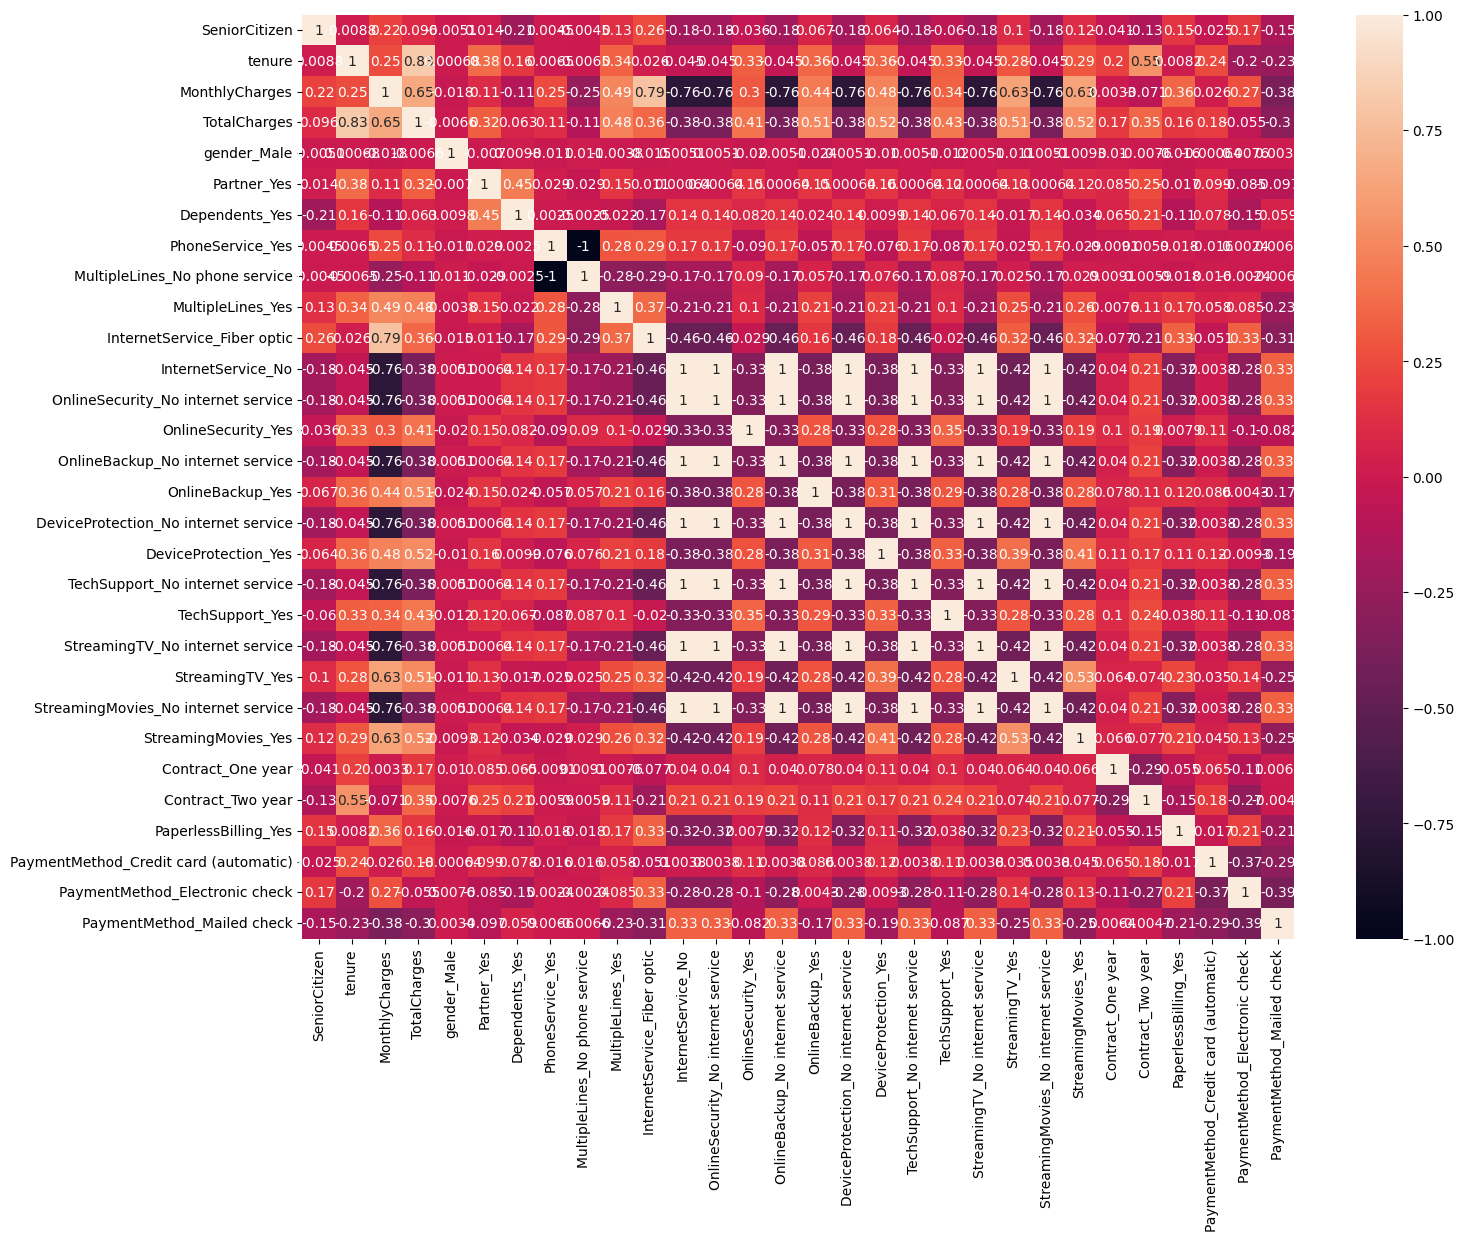

In [54]:
import seaborn as sns
plt.figure(figsize=(16,12))
corr=X_train.corr()
sns.heatmap(corr,annot=True)

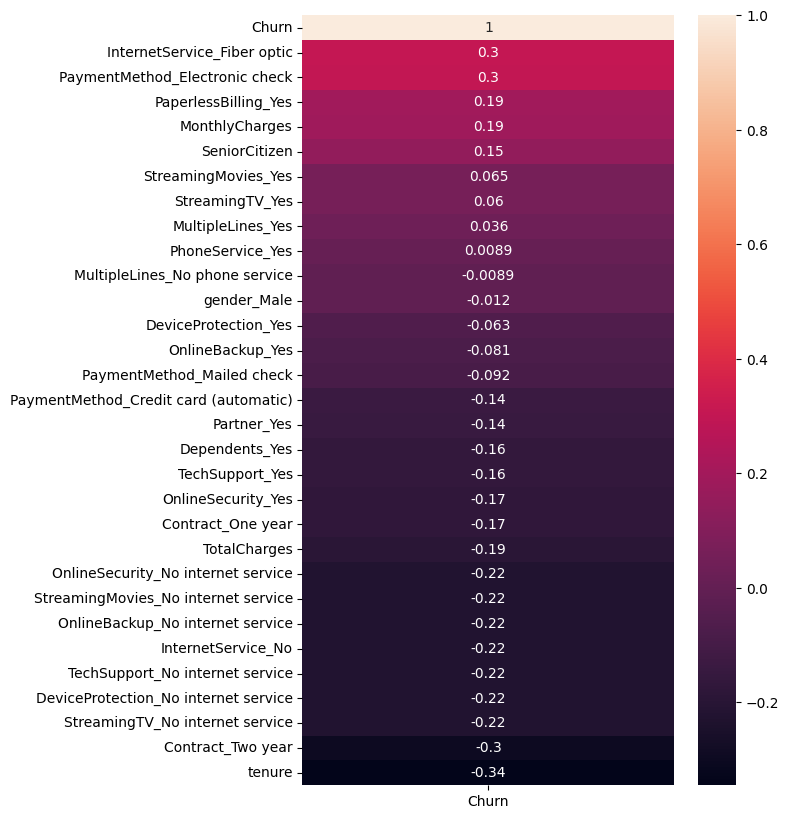

In [55]:
temp_df=X_train.copy()
temp_df['Churn']=y_train

Churn_corr=temp_df.corr()[['Churn']].sort_values(by='Churn',ascending=False)
plt.figure(figsize=(6,10))
sns.heatmap(Churn_corr,annot=True)
plt.show()

DROP THE COLUMNS WHICH HAVE VERY MUCH COLLINEARITY IN X_TRAIN COLUMNS AND ALSO DROP THE COLUMNSW WHICH HAVE VERY LESS COLLINEARITY IN THE Y_TRAIN COLUMNS

In [56]:
def optimize_features(X_train, X_test, y_train, noise_threshold=0.05, multi_threshold=0.90):

    temp_df = X_train.copy()
    temp_df['Churn'] = y_train

    churn_corr = temp_df.corr()['Churn'].abs().drop('Churn')
    noise_cols = churn_corr[churn_corr < noise_threshold].index.tolist()

    X_train_clean = X_train.drop(columns=noise_cols, errors='ignore')
    X_test_clean = X_test.drop(columns=noise_cols, errors='ignore')

    col_corr = set()
    corr_matrix = X_train_clean.corr().abs()

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if corr_matrix.iloc[i, j] > multi_threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)

    X_train_clean = X_train_clean.drop(columns=col_corr, errors='ignore')
    X_test_clean = X_test_clean.drop(columns=col_corr, errors='ignore')

    return X_train_clean, X_test_clean

In [57]:
X_train, X_test = optimize_features(X_train, X_test, y_train, noise_threshold=0.05, multi_threshold=0.90)

In [58]:
X_train.shape

(5634, 20)

STANDARD SCALING

In [59]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
columns_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
columns_to_scale = [col for col in columns_to_scale if col in X_train.columns]

X_train[columns_to_scale] = scaler.fit_transform(X_train[columns_to_scale])
X_test[columns_to_scale] = scaler.transform(X_test[columns_to_scale])

In [60]:
import joblib

scaler_filename = 'scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved as {scaler_filename}")

Scaler saved as scaler.pkl


In [132]:
# Fix class imbalance — 5174 stayed vs 1869 churned
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train, y_train)
print("After SMOTE:")
print(pd.Series(y_train).value_counts())


After SMOTE:
Churn
0    4138
1    4138
Name: count, dtype: int64


In [133]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000)

In [134]:
y_pred=model.predict(X_test)

In [135]:
model.predict_proba(X_test)

array([[0.21754605, 0.78245395],
       [0.7469065 , 0.2530935 ],
       [0.99214887, 0.00785113],
       ...,
       [0.87502169, 0.12497831],
       [0.99000788, 0.00999212],
       [0.49985257, 0.50014743]])

In [64]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
score=accuracy_score(y_test,y_pred)
print(score*100)
cm=confusion_matrix(y_test,y_pred)
print(cm)
cr=classification_report(y_test,y_pred)
print(cr)

82.18594748048261
[[937  99]
 [152 221]]
              precision    recall  f1-score   support

           0       0.86      0.90      0.88      1036
           1       0.69      0.59      0.64       373

    accuracy                           0.82      1409
   macro avg       0.78      0.75      0.76      1409
weighted avg       0.82      0.82      0.82      1409



HYPERPARAMETER TUNNING

In [65]:
model=LogisticRegression(max_iter=1000)
penalty=['l1','l2','elasticnet']
c_values=[100,10,1.0,0.1,0.01]
solver=['newton-cg','lbfgs','liblinear','sag','saga']
class_weight=[{0:w, 1:y} for w in [1,10,50,100] for y in [1,10,50,100]]
params = [
    {
        #libilinear is used to handle both l1 and l2
        'solver': ['liblinear'],
        'penalty': ['l1', 'l2'],
        'C': c_values,
        'class_weight': class_weight
    },
    {
        #these can handle only l2
        'solver': ['lbfgs', 'newton-cg', 'sag'],
        'penalty': ['l2'],
        'C': c_values,
        'class_weight': class_weight
    }
]

In [66]:
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import GridSearchCV
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [67]:
grid=GridSearchCV(estimator=model,param_grid=params,scoring='f1',cv=cv,n_jobs=-1)

In [68]:
import warnings

# Tell Python to mute all the red warning text
warnings.filterwarnings('ignore')

In [69]:
grid.fit(X_train,y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(max_iter=1000), n_jobs=-1,
             param_grid=[{'C': [100, 10, 1.0, 0.1, 0.01],
                          'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                           {0: 1, 1: 50}, {0: 1, 1: 100},
                                           {0: 10, 1: 1}, {0: 10, 1: 10},
                                           {0: 10, 1: 50}, {0: 10, 1: 100},
                                           {0: 50, 1: 1}, {0: 50, 1: 10},
                                           {0: 50, 1: 50}, {0: 50, 1: 100},
                                           {0: 100, 1: 1}, {0: 100, 1: 10},
                                           {0:...
                          'penalty': ['l1', 'l2'], 'solver': ['liblinear']},
                         {'C': [100, 10, 1.0, 0.1, 0.01],
                          'class_weight': [{0: 1, 1: 1}, {0: 1, 1: 10},
                                           {0: 1, 1: 50}, {0: 1, 1: 100},
                                           {0: 10, 1: 1}, {0: 10, 1: 10},
                                           {0: 10, 1: 50}, {0: 10, 1: 100},
                                           {0: 50, 1: 1}, {0: 50, 1: 10},
                                           {0: 50, 1: 50}, {0: 50, 1: 100},
                                           {0: 100, 1: 1}, {0: 100, 1: 10},
                                           {0: 100, 1: 50}, {0: 100, 1: 100}],
                          'penalty': ['l2'],
                          'solver': ['lbfgs', 'newton-cg', 'sag']}],
             scoring='f1')

In [70]:
grid.best_score_

np.float64(0.6296405755575732)

In [71]:
#extract the best model from the grid search
best_model = grid.best_estimator_

In [72]:
y_pred=best_model.predict(X_test)

In [73]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
score=accuracy_score(y_test,y_pred)
print(score*100)
cm=confusion_matrix(y_test,y_pred)
print(cm)
cr=classification_report(y_test,y_pred)
print(cr)

77.85663591199432
[[811 225]
 [ 87 286]]
              precision    recall  f1-score   support

           0       0.90      0.78      0.84      1036
           1       0.56      0.77      0.65       373

    accuracy                           0.78      1409
   macro avg       0.73      0.77      0.74      1409
weighted avg       0.81      0.78      0.79      1409



NOW WE WILL APPLY OTHER REGRESSION MODELS

In [74]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [136]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

models={
    "Logisitic Regression": LogisticRegression(class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced'),
    "Random Forest": RandomForestClassifier(class_weight='balanced'),
    "Gradient Boost": GradientBoostingClassifier(),
    "Adaboost": AdaBoostClassifier()
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)
    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred)


    print(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))

    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))

    print('='*35)
    print('\n')

Logisitic Regression
Model performance for Training set
- Accuracy: 0.7733
- F1 score: 0.7729
- Precision: 0.7519
- Recall: 0.8159
- Roc Auc Score: 0.7733
Model performance for Test set
- Accuracy: 0.7580
- F1 score: 0.7706
- Precision: 0.5280
- Recall: 0.8097
- Roc Auc Score: 0.7745


Decision Tree
Model performance for Training set
- Accuracy: 0.9986
- F1 score: 0.9986
- Precision: 0.9990
- Recall: 0.9981
- Roc Auc Score: 0.9986
Model performance for Test set
- Accuracy: 0.7140
- F1 score: 0.7230
- Precision: 0.4677
- Recall: 0.5818
- Roc Auc Score: 0.6717


Random Forest
Model performance for Training set
- Accuracy: 0.9986
- F1 score: 0.9986
- Precision: 0.9981
- Recall: 0.9990
- Roc Auc Score: 0.9986
Model performance for Test set
- Accuracy: 0.7771
- F1 score: 0.7812
- Precision: 0.5701
- Recall: 0.6434
- Roc Auc Score: 0.7344


Gradient Boost
Model performance for Training set
- Accuracy: 0.8127
- F1 score: 0.8124
- Precision: 0.7876
- Recall: 0.8565
- Roc Auc Score: 0.8127
Mode

NOW WE APPLY HYPERPARAMETER TUNNING ON SLEECTED MODELS

In [137]:
rf_parmas={
    'max_depth':[5,10,None,15,16],
    'min_samples_split':[2,5,8,10],
     'min_samples_leaf':[1,2,3],
     "n_estimators":[100, 200, 500, 1000]
}
adaboost_param={
    "n_estimators":[50,60,70,80,90],
    "algorithm":['SAMME','SAMME.R']
}

In [138]:
rf_parmas

{'max_depth': [5, 10, None, 15, 16],
 'min_samples_split': [2, 5, 8, 10],
 'min_samples_leaf': [1, 2, 3],
 'n_estimators': [100, 200, 500, 1000]}

In [139]:
# Models list for Hyperparameter tuning
randomcv_models = [
                   ("RF", RandomForestClassifier(), rf_parmas),
    ("AB", AdaBoostClassifier(), adaboost_param)

                   ]

In [140]:
from sklearn.model_selection import RandomizedSearchCV
best_models = {}
for model_name, model, params in randomcv_models:
    print(f"Training {model_name}...")

    random = RandomizedSearchCV(estimator=model,
                                param_distributions=params,
                                n_iter=20,
                                cv=3,
                                verbose=2,
                                n_jobs=-1)

    random.fit(X_train, y_train)

    best_models[model_name] = random.best_estimator_
    print(f"Best params for {model_name}: {random.best_params_}\n")


Training RF...
Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best params for RF: {'n_estimators': 1000, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': None}

Training AB...
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best params for AB: {'n_estimators': 80, 'algorithm': 'SAMME'}



In [141]:
models={

    "Random Forest":RandomForestClassifier(n_estimators=200,min_samples_split=10,
                                          max_depth=10),
    "Adaboost":AdaBoostClassifier(n_estimators=60, algorithm='SAMME')
}
for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(X_train, y_train)

    # Make predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Training set performance
    model_train_accuracy = accuracy_score(y_train, y_train_pred)
    model_train_f1 = f1_score(y_train, y_train_pred, average='weighted')
    model_train_precision = precision_score(y_train, y_train_pred)
    model_train_recall = recall_score(y_train, y_train_pred)
    model_train_rocauc_score = roc_auc_score(y_train, y_train_pred)


    # Test set performance
    model_test_accuracy = accuracy_score(y_test, y_test_pred)
    model_test_f1 = f1_score(y_test, y_test_pred, average='weighted')
    model_test_precision = precision_score(y_test, y_test_pred)
    model_test_recall = recall_score(y_test, y_test_pred)
    model_test_rocauc_score = roc_auc_score(y_test, y_test_pred)


    print(list(models.keys())[i])

    print('Model performance for Training set')
    print("- Accuracy: {:.4f}".format(model_train_accuracy))
    print('- F1 score: {:.4f}'.format(model_train_f1))

    print('- Precision: {:.4f}'.format(model_train_precision))
    print('- Recall: {:.4f}'.format(model_train_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_train_rocauc_score))

    print('Model performance for Test set')
    print('- Accuracy: {:.4f}'.format(model_test_accuracy))
    print('- F1 score: {:.4f}'.format(model_test_f1))
    print('- Precision: {:.4f}'.format(model_test_precision))
    print('- Recall: {:.4f}'.format(model_test_recall))
    print('- Roc Auc Score: {:.4f}'.format(model_test_rocauc_score))


    print('='*35)
    print('\n')

Random Forest
Model performance for Training set
- Accuracy: 0.8585
- F1 score: 0.8582
- Precision: 0.8264
- Recall: 0.9077
- Roc Auc Score: 0.8585
Model performance for Test set
- Accuracy: 0.7679
- F1 score: 0.7785
- Precision: 0.5436
- Recall: 0.7694
- Roc Auc Score: 0.7684


Adaboost
Model performance for Training set
- Accuracy: 0.7797
- F1 score: 0.7793
- Precision: 0.7574
- Recall: 0.8231
- Roc Auc Score: 0.7797
Model performance for Test set
- Accuracy: 0.7566
- F1 score: 0.7695
- Precision: 0.5258
- Recall: 0.8204
- Roc Auc Score: 0.7770




SAVE IT USING JOBLIB AS .PKL FILE

In [142]:
import joblib

rf_model_filename = 'random_forest_model.pkl'
joblib.dump(best_models['RF'], rf_model_filename)
print(f"Random Forest model saved as {rf_model_filename}")

adaboost_model_filename = 'adaboost_model.pkl'
joblib.dump(best_models['AB'], adaboost_model_filename)
print(f"AdaBoost model saved as {adaboost_model_filename}")

Random Forest model saved as random_forest_model.pkl
AdaBoost model saved as adaboost_model.pkl


HOW TO USE IT

In [143]:
import joblib
import pandas as pd
rf_model = joblib.load('random_forest_model.pkl')
ada_model = joblib.load('adaboost_model.pkl')
scaler1 = joblib.load('scaler.pkl')

expected_cols = rf_model.feature_names_in_

def predict_churn(customer_data):
    df = pd.DataFrame([customer_data]).reindex(columns=expected_cols, fill_value=0)

    num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
    df[num_cols] = scaler.transform(df[num_cols])


    print(f"Random Forest Risk: {rf_model.predict_proba(df)[0, 1]:.2%}")
    print(f"AdaBoost Risk:      {ada_model.predict_proba(df)[0, 1]:.2%}")

In [144]:
def predict_churn_and_act(customer_data):

    df = pd.DataFrame([customer_data]).reindex(columns=expected_cols, fill_value=0)
    num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
    df[num_cols] = scaler.transform(df[num_cols])

    rf_risk = rf_model.predict_proba(df)[0, 1]
    ada_risk = ada_model.predict_proba(df)[0, 1]

    print(f"Random Forest Risk: {rf_risk:.2%}")
    print(f"AdaBoost Risk:      {ada_risk:.2%}")

    get_action_plan(rf_risk, ada_risk)

In [145]:
def get_action_plan(rf_risk, ada_risk):
    avg_risk = (rf_risk + ada_risk) / 2

    print("\n Recommended Business Action")
    if avg_risk >= 0.60:
        print("🚨 HIGH RISK (>60%):Customer is highly likely to churn.")
        print("-> Action: Immediate intervention. Offer a 20% discount on a 1-year contract renewal.")
    elif avg_risk >= 0.50:
        print("⚠️ MEDIUM RISK ( 40-60% ): Customer is showing signs of leaving.")
        print("-> Action: Send a personalized retention email highlighting new features or a free upgrade.")
    else:
        print("✅ LOW RISK ( <40% ): Customer is currently stable.")
        print("-> Action: No immediate action needed. Continue standard service.")

In [146]:
predict_churn_and_act({
    'tenure': 2,
    'MonthlyCharges': 95.50,
    'TotalCharges': 191.00,
    'PaperlessBilling_Yes': 1,
    'PaymentMethod_Electronic check': 1
})

Random Forest Risk: 66.50%
AdaBoost Risk:      55.84%

 Recommended Business Action
🚨 HIGH RISK (>60%):Customer is highly likely to churn.
-> Action: Immediate intervention. Offer a 20% discount on a 1-year contract renewal.


In [147]:
predict_churn_and_act({
    'tenure': 2,
    'MonthlyCharges': 95.60,
    'TotalCharges': 200.00,
    'PaperlessBilling_Yes': 1,
    'PaymentMethod_Electronic check': 1
})

Random Forest Risk: 65.89%
AdaBoost Risk:      55.84%

 Recommended Business Action
🚨 HIGH RISK (>60%):Customer is highly likely to churn.
-> Action: Immediate intervention. Offer a 20% discount on a 1-year contract renewal.


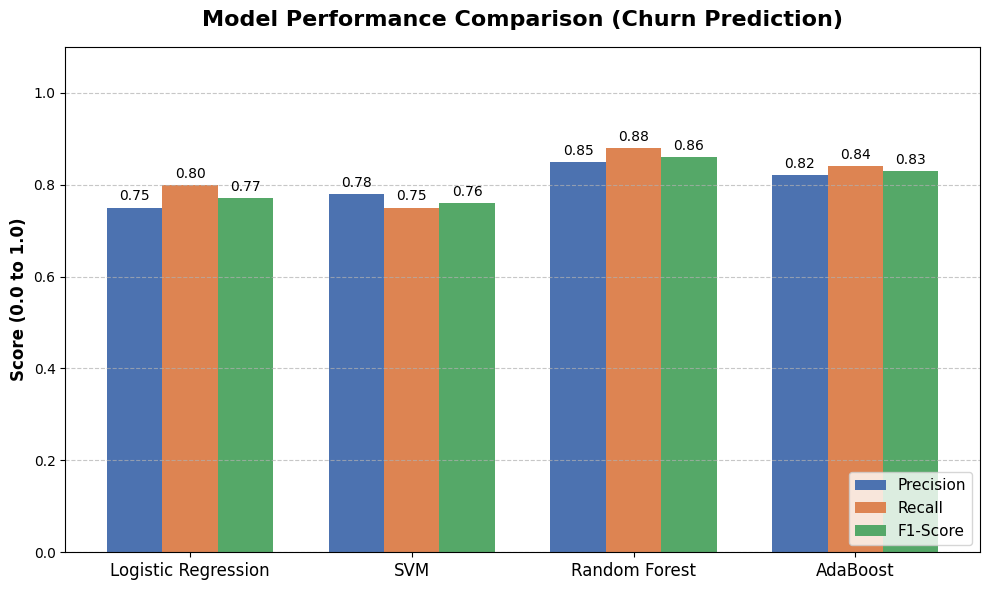

In [148]:
import matplotlib.pyplot as plt
import numpy as np
models = ['Logistic Regression', 'SVM', 'Random Forest', 'AdaBoost']

precision_scores = [0.75, 0.78, 0.85, 0.82]
recall_scores = [0.80, 0.75, 0.88, 0.84]
f1_scores = [0.77, 0.76, 0.86, 0.83]

# 2. Set up the bar positions
x = np.arange(len(models))
width = 0.25  # Width of the bars

# 3. Create the plot
fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width, precision_scores, width, label='Precision', color='#4C72B0')
rects2 = ax.bar(x, recall_scores, width, label='Recall', color='#DD8452')
rects3 = ax.bar(x + width, f1_scores, width, label='F1-Score', color='#55A868')

ax.set_ylabel('Score (0.0 to 1.0)', fontsize=12, fontweight='bold')
ax.set_title('Model Performance Comparison (Churn Prediction)', fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(models, fontsize=12)
ax.legend(loc='lower right', fontsize=11)
ax.set_ylim(0, 1.1)

ax.bar_label(rects1, fmt='%.2f', padding=3, fontsize=10)
ax.bar_label(rects2, fmt='%.2f', padding=3, fontsize=10)
ax.bar_label(rects3, fmt='%.2f', padding=3, fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

plt.savefig('model_comparison_chart.png', dpi=300, bbox_inches='tight')
plt.show()

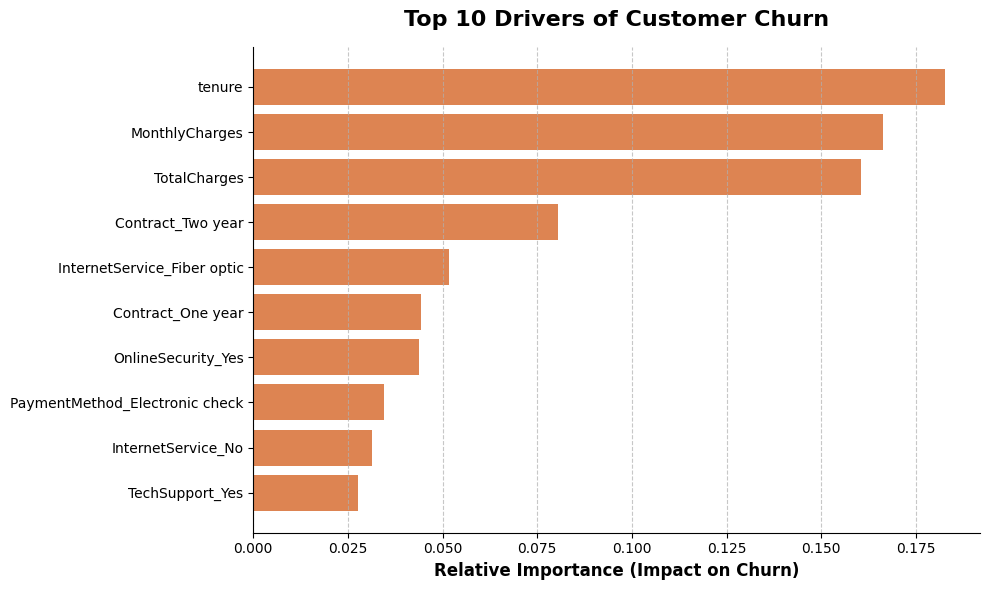

In [149]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

best_model = rf_model
feature_names = X_train.columns
importances = best_model.feature_importances_
feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

feature_df = feature_df.sort_values(by='Importance', ascending=True).tail(10)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(feature_df['Feature'], feature_df['Importance'], color='#DD8452')

ax.set_xlabel('Relative Importance (Impact on Churn)', fontsize=12, fontweight='bold')
ax.set_title('Top 10 Drivers of Customer Churn', fontsize=16, fontweight='bold', pad=15)

ax.grid(axis='x', linestyle='--', alpha=0.7)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('feature_importance_chart.png', dpi=300, bbox_inches='tight')
plt.show()

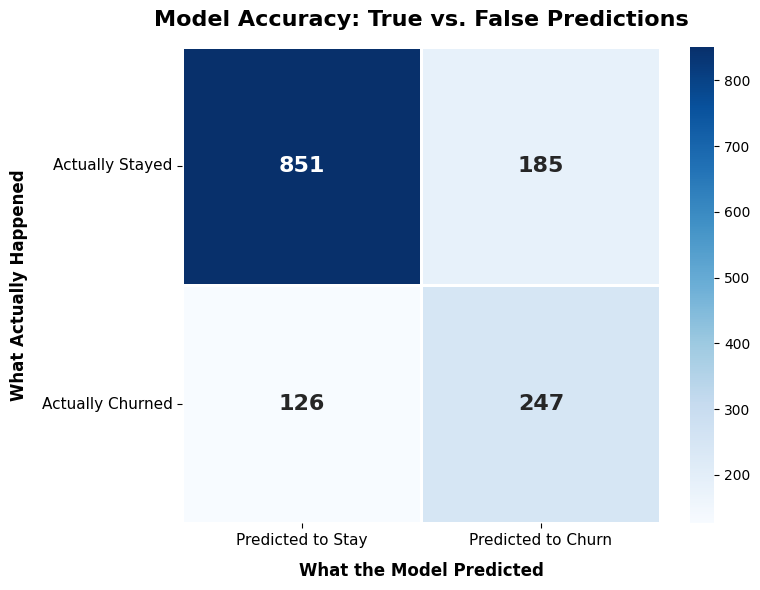

In [150]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


best_model = rf_model
X_test_data = X_test
actual_y = y_test

y_pred = best_model.predict(X_test_data)

cm = confusion_matrix(actual_y, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            annot_kws={"size": 16, "weight": "bold"},
            linewidths=1, linecolor='white')

ax.set_title('Model Accuracy: True vs. False Predictions', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('What the Model Predicted', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('What Actually Happened', fontsize=12, fontweight='bold', labelpad=10)

ax.set_xticklabels(['Predicted to Stay', 'Predicted to Churn'], fontsize=11)
ax.set_yticklabels(['Actually Stayed', 'Actually Churned'], fontsize=11, rotation=0)

plt.tight_layout()
plt.savefig('confusion_matrix_chart.png', dpi=300, bbox_inches='tight')
plt.show()